# Module 2, Lesson 2: Working with USGS Time Series Data

## Accessing and exploring real monitoring data with Python

In the previous exercise, we used the **USGS Water Data website and Excel** to explore a time series manually.

In this notebook, we will repeat the same basic workflow using Python, but we will retrieve the data **directly from USGS**. No CSV download is needed.

We will use:

**Shoal Creek at W 12th St, Austin, TX**  
**USGS Monitoring Location: USGS-08156800**

For the worked example, we will use **discharge**.

At the end, you will repeat the analysis using **stage**.

## ✅ What you will accomplish in this lesson

By the end of this notebook, you will be able to:

✅ Retrieve USGS time series data directly in Python  
✅ Identify a monitoring location and parameter code  
✅ Inspect the returned data in a Pandas DataFrame  
✅ Check the time range of the retrieved observations  
✅ Work with timestamps and sampling intervals  
✅ Calculate basic summary statistics  
✅ Plot a time series  
✅ Detect missing records from timestamp gaps  
✅ Insert missing timestamps while leaving their values blank  
✅ Compare monthly distributions with box plots

## <font color="blue"><b>PART 1: SETTING UP</b></font>

USGS provides a Python package called `dataretrieval` that connects directly to the USGS Water Data APIs.

We will use the newer `waterdata` module.

You may find older examples online that use functions such as `nwis.get_iv()` and `nwis.get_dv()`. In this class, we will use the newer `waterdata` interface.

### About `dataretrieval` and `waterdata`

[`dataretrieval`](https://doi-usgs.github.io/dataretrieval-python/) is the USGS-supported Python package for accessing USGS water data programmatically.

Within that package, the [`waterdata`](https://doi-usgs.github.io/dataretrieval-python/reference/waterdata.html) module connects to the newer USGS Water Data APIs and provides functions such as `get_continuous()` and `get_daily()`.

In this class, we will use `waterdata` so the code matches the current USGS Water Data system.

### Installing the USGS packages

The following command installs the Python packages used in this notebook:

`!pip install dataretrieval folium`

- `!` tells Colab to run a command-line command rather than Python code.
- `pip install` installs Python packages.
- `dataretrieval` is the USGS package we use to access water data.
- `folium` is used for the optional interactive map at the end.

**Note:** You may sometimes see `-q` added after `pip install`. The `-q` means **quiet** and simply reduces the amount of installation output displayed.

In [ ]:
# Install the USGS dataretrieval package

!pip install -q dataretrieval folium

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 253.8/253.8 kB 3.9 MB/s eta 0:00:00


In [ ]:
# Import packages

import pandas as pd
import matplotlib.pyplot as plt
from dataretrieval import waterdata

## <font color="blue"><b>PART 2: DEFINE THE MONITORING LOCATION</b></font>

USGS identifies each monitoring location with a unique ID.

USGS also uses **parameter codes** to identify the variable being measured.

For this example:

- `USGS-08156800` = Shoal Creek at W 12th St
- `00060` = discharge
- `00065` = gage height (stage)

### USGS parameter codes

USGS uses five-digit parameter codes to identify measured variables.

A searchable list of parameter codes is available here:

[USGS Parameter Code Information](https://waterdata.usgs.gov/code-dictionary)

For this example:

- `00060` = discharge
- `00065` = gage height (stage)

In [ ]:
# Define the monitoring location and parameter

site_id = 'USGS-08156800'
parameter_code = '00060'   # Discharge

print(f'Monitoring location: {site_id}')
print(f'Parameter code: {parameter_code}')

Monitoring location: USGS-08156800
Parameter code: 00060


### Retrieve information about the monitoring location

Before retrieving the time series, we can ask USGS for information about the site itself.

In [ ]:
# Retrieve monitoring location information

site_info, site_metadata = waterdata.get_monitoring_locations(
    monitoring_location_id=site_id,
    skip_geometry=True
)

site_info[
    ['monitoring_location_id',
     'monitoring_location_name',
     'site_type',
     'state_name']
]

,monitoring_location_id,monitoring_location_name,site_type,state_name
0,USGS-08156800,"Shoal Ck at W 12th St, Austin, TX",Stream,Texas


## <font color="blue"><b>PART 3: RETRIEVE THE TIME SERIES</b></font>

Now we will retrieve continuous discharge observations directly from USGS.

`get_continuous()` retrieves high-frequency sensor observations. If we do not specify a time range, USGS returns the most recent year of available observations.

This replaces the manual steps of selecting **Download data** and opening `primary-time-series.csv`.

In [ ]:
# Retrieve continuous discharge data directly from USGS

df_flow, metadata = waterdata.get_continuous(
    monitoring_location_id=site_id,
    parameter_code=parameter_code
)

print(f'Number of records retrieved: {len(df_flow)}')

Number of records retrieved: 118862


## <font color="blue"><b>PART 4: INSPECT THE DATAFRAME</b></font>

As with any new dataset, start by looking at its structure before doing any analysis.

In [ ]:
# Display the first few rows

df_flow.head()

,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,time,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id
0,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,2025-09-10 15:40:00+00:00,0.0,ft^3/s,Provisional,None,2025-12-30 20:32:18.997590+00:00,3cc035ac-1c58-4a9b-9766-236505a9965b
1,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,2025-09-10 15:45:00+00:00,0.0,ft^3/s,Provisional,None,2025-12-30 20:32:18.997590+00:00,092de738-4398-4b77-92d1-ec956a4ce394
2,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,2025-09-10 15:50:00+00:00,0.0,ft^3/s,Provisional,None,2025-12-30 20:32:18.997590+00:00,32792941-5b84-47b1-9185-7bc37c203204
3,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,2025-09-10 15:55:00+00:00,0.0,ft^3/s,Provisional,None,2025-12-30 20:32:18.997590+00:00,1adb1088-a7ca-4e2b-9765-188f7420ee84
4,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,2025-09-10 16:00:00+00:00,0.0,ft^3/s,Provisional,None,2025-12-30 20:32:18.997590+00:00,09b2f279-7122-4334-a00f-fc895595039a


In [ ]:
# Display the column names

print('Column names:')
print(df_flow.columns)

Column names:
Index(['geometry', 'time_series_id', 'monitoring_location_id',
       'parameter_code', 'statistic_id', 'time', 'value', 'unit_of_measure',
       'approval_status', 'qualifier', 'last_modified', 'continuous_id'],
      dtype='object')


In [ ]:
# Summarize the DataFrame structure

df_flow.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 118862 entries, 0 to 118861
Data columns (total 12 columns):
 #   Column                  Non-Null Count   Dtype              
---  ------                  --------------   -----              
 0   geometry                118862 non-null  geometry           
 1   time_series_id          118862 non-null  object             
 2   monitoring_location_id  118862 non-null  object             
 3   parameter_code          118862 non-null  object             
 4   statistic_id            118862 non-null  object             
 5   time                    118862 non-null  datetime64[ns, UTC]
 6   value                   118862 non-null  float64            
 7   unit_of_measure         118862 non-null  object             
 8   approval_status         118862 non-null  object             
 9   qualifier               152 non-null     object             
 10  last_modified           118862 non-null  datetime64[ns, UTC]
 11  continuous_id     

For this exercise, the most important columns are:

- `time` = timestamp
- `value` = discharge measurement
- `unit_of_measure` = measurement units
- `approval_status` = whether the value is approved or provisional

The API also returns metadata columns that describe the monitoring location and time series.

In [ ]:
# Keep a few important columns for inspection

df_flow[['time', 'value', 'unit_of_measure', 'approval_status']].head()

,time,value,unit_of_measure,approval_status
0,2025-09-10 15:40:00+00:00,0.0,ft^3/s,Provisional
1,2025-09-10 15:45:00+00:00,0.0,ft^3/s,Provisional
2,2025-09-10 15:50:00+00:00,0.0,ft^3/s,Provisional
3,2025-09-10 15:55:00+00:00,0.0,ft^3/s,Provisional
4,2025-09-10 16:00:00+00:00,0.0,ft^3/s,Provisional


## <font color="blue"><b>PART 5: WORKING WITH TIME</b></font>

In Excel, the downloaded timestamp looked like:

```text
2026-01-06 03:30:00+00:00
```

and we had to convert it before Excel could use it as a date and time.

When we retrieve the data directly with `waterdata`, the `time` column is already stored as a Pandas datetime.

The `+00:00` indicates that the timestamp is expressed in **UTC**.

In [ ]:
# Check the timestamp data type

print(f'Timestamp data type: {df_flow['time'].dtype}')

Timestamp data type: datetime64[ns, UTC]


💡 **Notice:** Python understands both the date/time and the UTC time-zone information. We do not need the Excel `LEFT()` and `VALUE()` steps.

### Sort observations from old to new

In [ ]:
# Sort observations from earliest to latest
df_flow = df_flow.sort_values('time')

# Reset the row numbers
df_flow = df_flow.reset_index(drop=True)

df_flow[['time', 'value']].head()

,time,value
0,2025-09-10 15:40:00+00:00,0.0
1,2025-09-10 15:45:00+00:00,0.0
2,2025-09-10 15:50:00+00:00,0.0
3,2025-09-10 15:55:00+00:00,0.0
4,2025-09-10 16:00:00+00:00,0.0


In [ ]:
df_flow[['time', 'value']].tail()

,time,value
118857,2026-09-10 15:05:00+00:00,0.0
118858,2026-09-10 15:10:00+00:00,0.0
118859,2026-09-10 15:10:00+00:00,0.0
118860,2026-09-10 15:15:00+00:00,0.0
118861,2026-09-10 15:15:00+00:00,0.0


### Check the time range of the retrieved data

Before analyzing the time series, check the first and last timestamps returned by USGS.

In [ ]:
# Check the first and last timestamps in the retrieved dataset

print(f'First timestamp: {df_flow['time'].min()}')
print(f'Last timestamp:  {df_flow['time'].max()}')

First timestamp: 2025-09-10 15:40:00+00:00
Last timestamp:  2026-09-10 15:15:00+00:00


### Selecting approved observations

USGS data may include both **provisional** and **approved** observations.

- **Provisional** data are preliminary observations that have not yet completed the USGS review process.
- **Approved** data have completed the review process.

In some periods, both provisional and approved observations may be returned for the same timestamp. This means that the dataset can contain more than one observation at the same time.

For this analysis, we will keep only the **approved** observations. This gives us one consistent time series for the remaining analysis.

In [ ]:
df_flow['approval_status'].value_counts()

,count
approval_status,
Approved,72225
Provisional,46637


In [ ]:
# Keep only approved observations
df_flow = df_flow[df_flow['approval_status'] == 'Approved']

# Check the number of observations after filtering
print(f'Number of approved observations: {len(df_flow)}')

Number of approved observations: 72225


We now use this filtered DataFrame for the remainder of the analysis, including summary statistics, plotting, and checking for missing observations.

### Check the time range of the data with only approved observations


In [ ]:
print(f'First timestamp: {df_flow['time'].min()}')
print(f'Last timestamp:  {df_flow['time'].max()}')

First timestamp: 2025-11-20 05:00:00+00:00
Last timestamp:  2026-08-03 15:45:00+00:00


## <font color="blue"><b>PART 6: BASIC SUMMARY STATISTICS</b></font>

We performed the same calculations manually in Excel.

Now calculate the mean, minimum, and maximum discharge.

In [ ]:
# Calculate basic statistics

mean_discharge = df_flow['value'].mean()
min_discharge = df_flow['value'].min()
max_discharge = df_flow['value'].max()

print(f'Mean discharge: {mean_discharge:.2f} ft^3/s')
print(f'Minimum discharge: {min_discharge:.2f} ft^3/s')
print(f'Maximum discharge: {max_discharge:.2f} ft^3/s')

Mean discharge: 7.07 ft^3/s
Minimum discharge: 0.00 ft^3/s
Maximum discharge: 2220.00 ft^3/s


### When did the maximum occur?

`idxmax()` returns the row location of the maximum value.

In [ ]:
# Find the time of the maximum discharge

max_row = df_flow.loc[df_flow['value'].idxmax()]

print(f'Maximum discharge: {max_row['value']:.2f} ft^3/s')
print(f'Time of maximum: {max_row['time']}')

Maximum discharge: 2220.00 ft^3/s
Time of maximum: 2026-06-15 08:45:00+00:00


In [ ]:
max_row

,78257
geometry,POINT (-97.75030522902125 30.276598027108964)
time_series_id,2abb693d2d934b0ca78c2dad65c591ad
monitoring_location_id,USGS-08156800
parameter_code,00060
statistic_id,00011
time,2026-06-15 08:45:00+00:00
value,2220.0
unit_of_measure,ft^3/s
approval_status,Approved
qualifier,None


### Observations above and below the mean

A logical condition such as

```python
df['value'] > mean_discharge
```

returns `True` or `False` for every observation.

In Python, `True` counts as 1, so `.sum()` gives the number of observations that meet the condition.

In [ ]:
# Count observations above and below the mean

above_mean = (df_flow['value'] > mean_discharge).sum()
below_mean = (df_flow['value'] < mean_discharge).sum()

print(f'Observations above the mean: {above_mean}')
print(f'Observations below the mean: {below_mean}')

Observations above the mean: 7107
Observations below the mean: 65118


## <font color="blue"><b>PART 7: TIME SERIES PLOT</b></font>

Create the same basic time series plot that we created in Excel.

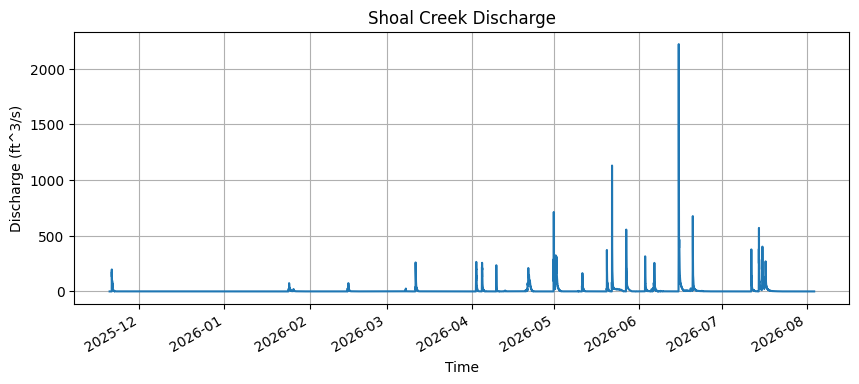

In [ ]:
# Plot discharge as a time series

plt.figure(figsize=(10, 4))
plt.plot(df_flow['time'], df_flow['value'])

plt.gcf().autofmt_xdate()
plt.title('Shoal Creek Discharge')
plt.xlabel('Time')
plt.ylabel('Discharge (ft^3/s)')
plt.grid(True)

plt.show()

### Compare with the USGS website

The USGS website uses a **custom nonlinear y-axis** for its discharge graph. This expands the lower discharge values while compressing the higher values.

The plot above uses a standard linear y-axis.

Ask:

1. What features are easy to see on the linear plot?
2. What features are easier to see on the USGS plot?
3. Why can the same data look different depending on the axis scale?

## <font color="blue"><b>PART 8: CHECK FOR MISSING RECORDS</b></font>

In the downloaded CSV, missing data did not necessarily appear as blank cells or `NaN`.

Instead, entire **timestamps were missing**.

The Shoal Creek time series is expected to contain observations every **5 minutes**. We can therefore look at the time difference between consecutive records.

In [ ]:
# Calculate the time between consecutive observations

df_flow['time_gap'] = df_flow['time'].diff()

df_flow[['time', 'time_gap']].head(10)

,time,time_gap
11794,2025-11-20 05:00:00+00:00,NaT
11795,2025-11-20 05:05:00+00:00,0 days 00:05:00
11796,2025-11-20 05:10:00+00:00,0 days 00:05:00
11797,2025-11-20 05:15:00+00:00,0 days 00:05:00
11798,2025-11-20 05:20:00+00:00,0 days 00:05:00
11799,2025-11-20 05:25:00+00:00,0 days 00:05:00
11800,2025-11-20 05:30:00+00:00,0 days 00:05:00
11801,2025-11-20 05:35:00+00:00,0 days 00:05:00
11802,2025-11-20 05:40:00+00:00,0 days 00:05:00
11803,2025-11-20 05:45:00+00:00,0 days 00:05:00


A normal observation should have a time difference of:

```text
0 days 00:05:00
```

Any interval longer than 5 minutes indicates that one or more expected records are missing.

In [ ]:
# Find time gaps larger than 5 minutes

gaps = df_flow[df_flow['time_gap'] > pd.Timedelta(minutes=5)]

print(f'Number of gaps larger than 5 minutes: {len(gaps)}')

gaps[['time', 'time_gap']].head()

Number of gaps larger than 5 minutes: 161


,time,time_gap
15668,2025-12-02 18:35:00+00:00,0 days 01:00:00
32753,2026-01-31 02:25:00+00:00,0 days 00:10:00
32836,2026-01-31 09:25:00+00:00,0 days 00:10:00
32844,2026-01-31 10:10:00+00:00,0 days 00:10:00
33026,2026-02-01 01:25:00+00:00,0 days 00:10:00


### Estimate the number of missing observations

This follows the same logic as the Excel equation:

```text
(time between records / expected 5-minute interval) - 1
```

We subtract 1 because the observation at the end of the interval is present.

In [ ]:
# Estimate the number of missing observations in each gap

df_flow['missing_records'] = (
    df_flow['time_gap'] / pd.Timedelta(minutes=5) - 1
).clip(lower=0).fillna(0).round().astype(int)

missing = df_flow[df_flow['missing_records'] > 0]

print(f'Total estimated missing observations: {df_flow["missing_records"].sum()}')

missing[['time', 'time_gap', 'missing_records']].head()

Total estimated missing observations: 1633


,time,time_gap,missing_records
15668,2025-12-02 18:35:00+00:00,0 days 01:00:00,11
32753,2026-01-31 02:25:00+00:00,0 days 00:10:00,1
32836,2026-01-31 09:25:00+00:00,0 days 00:10:00,1
32844,2026-01-31 10:10:00+00:00,0 days 00:10:00,1
33026,2026-02-01 01:25:00+00:00,0 days 00:10:00,1


### Insert the missing timestamps

So far, we identified where timestamps are missing.

We can also create a complete 5-minute time index and insert those missing timestamps into the DataFrame. The new rows are added, but the measurement values are left blank (`NaN`) for now.

This is useful because the time series now has a regular 5-minute structure without pretending that we know the missing values.

In [ ]:
# Create a complete 5-minute time index

full_time = pd.date_range(
    start=df_flow['time'].min(),
    end=df_flow['time'].max(),
    freq='5min'
)

# Reindex the DataFrame so missing timestamps are inserted
# Measurement values remain blank (NaN)

df_flow_complete = (
    df_flow.set_index('time')
      .reindex(full_time)
      .rename_axis('time')
      .reset_index()
)

print(f'Original number of rows: {len(df_flow)}')
print(f'Rows after inserting missing timestamps: {len(df_flow_complete)}')

df_flow_complete.head()

Original number of rows: 72225
Rows after inserting missing timestamps: 73858


,time,geometry,time_series_id,monitoring_location_id,parameter_code,statistic_id,value,unit_of_measure,approval_status,qualifier,last_modified,continuous_id,time_gap,missing_records
0,2025-11-20 05:00:00+00:00,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,0.0,ft^3/s,Approved,None,2026-03-18 19:42:14.966251+00:00,250c3c2f-8469-42b6-83eb-20385651851b,NaT,0.0
1,2025-11-20 05:05:00+00:00,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,0.0,ft^3/s,Approved,None,2026-03-18 19:42:14.966251+00:00,6aa090e8-6d6f-4249-8f7a-a2d86b1b2e11,0 days 00:05:00,0.0
2,2025-11-20 05:10:00+00:00,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,0.0,ft^3/s,Approved,None,2026-03-18 19:42:14.966251+00:00,2c67bef8-50cb-4bc3-a240-3cdbd0f06a24,0 days 00:05:00,0.0
3,2025-11-20 05:15:00+00:00,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,0.0,ft^3/s,Approved,None,2026-03-18 19:42:14.966251+00:00,61149b37-132d-435f-8e29-8463d1231429,0 days 00:05:00,0.0
4,2025-11-20 05:20:00+00:00,POINT (-97.75031 30.2766),2abb693d2d934b0ca78c2dad65c591ad,USGS-08156800,00060,00011,0.0,ft^3/s,Approved,None,2026-03-18 19:42:14.966251+00:00,5efef526-108d-4def-8e21-9de0c181f76b,0 days 00:05:00,0.0


💡 **Important:** A dataset can contain no blank values and still have missing data. In time series data, always check whether the expected timestamps are present.

## <font color="blue"><b>PART 9: TIMESERIES PLOTS</b></font>

Let's make some time series plots:
1. The entier period
2. Selected start and end dates


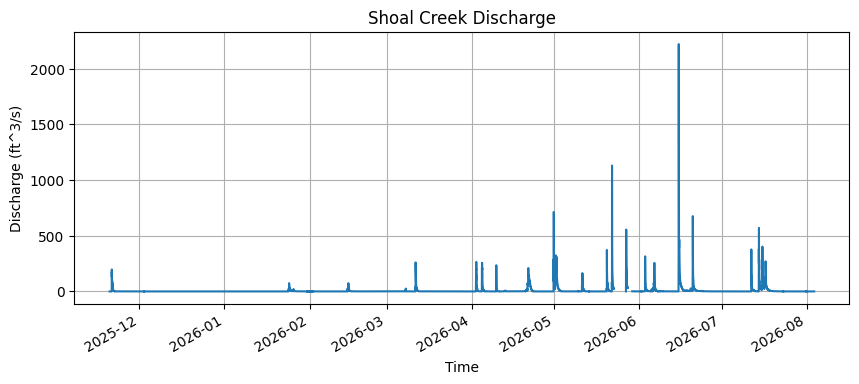

In [ ]:
# Plot discharge as a time series

plt.figure(figsize=(10, 4))
plt.plot(df_flow_complete['time'], df_flow_complete['value'])

plt.gcf().autofmt_xdate()
plt.title('Shoal Creek Discharge')
plt.xlabel('Time')
plt.ylabel('Discharge (ft^3/s)')
plt.grid(True)

plt.show()

### **Selecting a date range**

The full time series provides an overview of the data.

In many analyses, we are interested in a specific time period, such as a day, a week, or a month. We can create a subset of the data by selecting a date range.

Lets select the seven-day period beginning at midnight on **May 15, 2026** and ending immediately before midnight on **June 15, 2026**.

In [ ]:
# Define start and end dates

start_date = '2026-05-15'
end_date = '2026-06-15'

df_subset_flow = df_flow_complete[
    (df_flow_complete['time'] >= start_date) &
    (df_flow_complete['time'] < end_date)
]

print(f'Number of records in subset: {len(df_subset_flow)}')


Number of records in subset: 8928


💡 **Check** How many data records you expect in an hourly dataset covering the start and end dates?

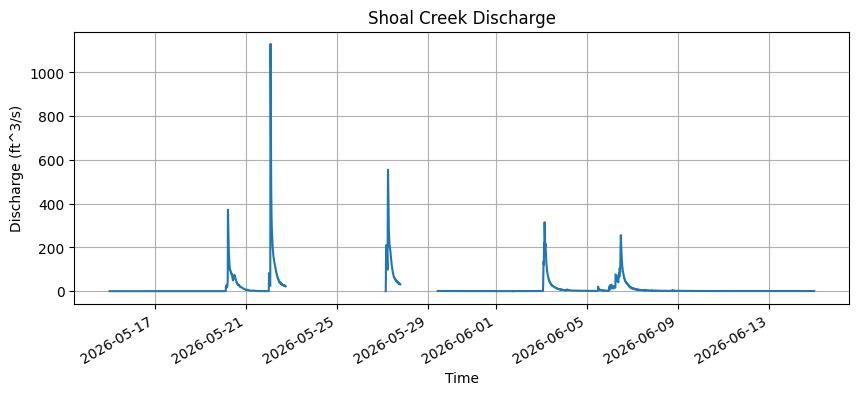

In [ ]:
# Plot a selected time period

plt.figure(figsize=(10, 4))
plt.plot(df_subset_flow['time'], df_subset_flow['value'])

plt.gcf().autofmt_xdate()
plt.title('Shoal Creek Discharge')
plt.xlabel('Time')
plt.ylabel('Discharge (ft^3/s)')
plt.grid(True)

plt.show()


## <font color="blue"><b>PART 10: MONTHLY SUMMARY</b></font>

A time series plot shows when changes occurred.

A box plot provides a compact way to compare the distribution of discharge among months.

In [ ]:
# Create a month column

df_flow_complete['month'] = df_flow_complete['time'].dt.month_name().str[:3]

month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
               'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

df_flow_complete['month'] = pd.Categorical(
    df_flow_complete['month'],
    categories=month_order,
    ordered=True
)

df_flow_complete[['time', 'value', 'month']].head()

,time,value,month
0,2025-11-20 05:00:00+00:00,0.0,Nov
1,2025-11-20 05:05:00+00:00,0.0,Nov
2,2025-11-20 05:10:00+00:00,0.0,Nov
3,2025-11-20 05:15:00+00:00,0.0,Nov
4,2025-11-20 05:20:00+00:00,0.0,Nov


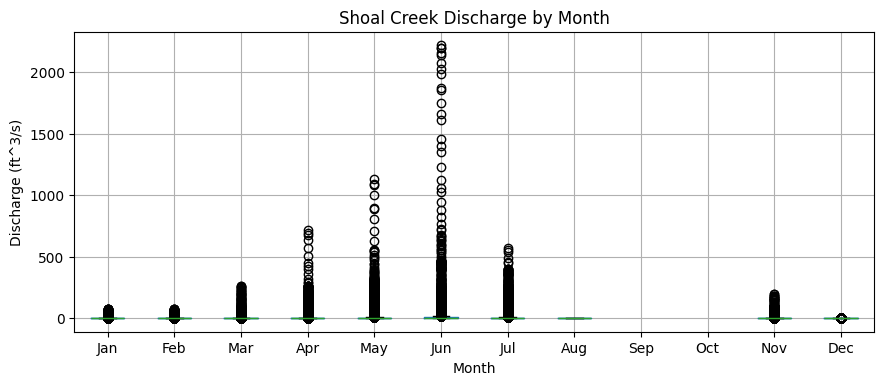

In [ ]:
# Boxplot of discharge by month

df_flow_complete.boxplot(column='value', by='month', figsize=(10, 4))

plt.title('Shoal Creek Discharge by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Discharge (ft^3/s)')
plt.grid(True)

plt.show()

### Box plot **without displaying outlier** points

By default, a box plot shows individual points beyond the whiskers. For this discharge dataset, there can be many of them.

We can hide those individual outlier markers while keeping the box, median, and whiskers:

```python
showfliers=False
```

This does **not** remove the observations from the data. It only changes how the box plot is displayed.

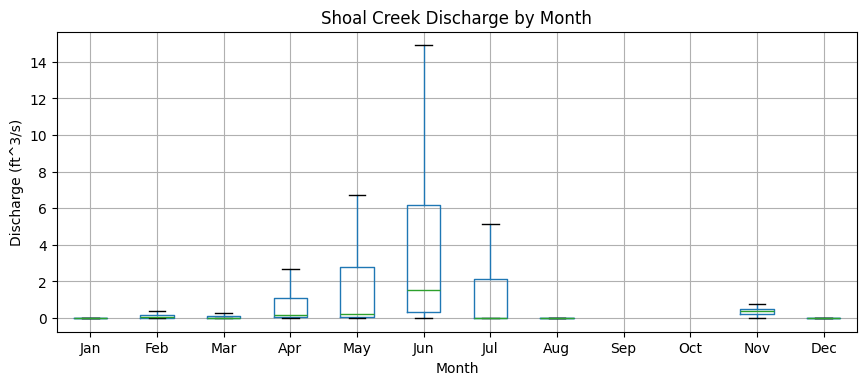

In [ ]:
# Boxplot of discharge by month without showing individual outlier points

df_flow_complete.boxplot(
    column='value',
    by='month',
    figsize=(10, 4),
    showfliers=False
)

plt.title('Shoal Creek Discharge by Month')
plt.suptitle('')
plt.xlabel('Month')
plt.ylabel('Discharge (ft^3/s)')
plt.grid(True)

plt.show()

## <font color="blue"><b>BONUS: MAKE INTERACTIVE PLOTS</b></font>

In [ ]:
import plotly.express as px

fig = px.line(df_subset_flow, x='time', y='value', title='Shoal Creek Discharge')
fig.update_layout(xaxis_title='Time', yaxis_title='Discharge (ft^3/s)')
fig.show()

# save the html
# figure_file = os.path.join(figures_folder, 'fig1_timeseries.html')
fig.write_html('fig1_timeseries.html')

## <font color="blue"><b>BONUS: MAP THE MONITORING LOCATION</b></font>

The Water Data API can also return spatial information about a monitoring location.

This is not needed for the time series analysis, but it shows that the same USGS service can provide both **data** and **location information**.

In [ ]:
# BONUS: Retrieve the monitoring location with its geometry

site_map, _ = waterdata.get_monitoring_locations(
    monitoring_location_id=site_id
)

site_map[['monitoring_location_id', 'monitoring_location_name', 'geometry']]

,monitoring_location_id,monitoring_location_name,geometry
0,USGS-08156800,"Shoal Ck at W 12th St, Austin, TX",POINT (-97.75031 30.2766)


In [ ]:
# BONUS: Create an interactive map

import folium

longitude = site_map.geometry.x.iloc[0]
latitude = site_map.geometry.y.iloc[0]
site_name = site_map['monitoring_location_name'].iloc[0]

m = folium.Map(
    location=[latitude, longitude],
    zoom_start=14
)

folium.Marker(
    [latitude, longitude],
    popup=f'{site_name}<br>{site_id}'
).add_to(m)


m.save('shoal_creek_map.html')

m


💡This interactive visualization can be shared outside the notebook. Because we did not mount Google Drive in this session, the HTML file is saved temporarily in Colab's `/content` folder. Files stored in `/content` will disappear when the Colab session ends, so download the file to your computer if you want to keep it.

1. Click the **folder icon** on the left.
2. Find `fig1_timeseries.html` and `shoal_creek_map.html`
3. Click the **three dots** next to the file.
4. Select **Download**.

Or we can use the following code to download it from Colab's temporary /content storage to your computer.

In [ ]:
from google.colab import files

files.download('fig1_timeseries.html')
files.download('shoal_creek_map.html')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>